# Yield Curve Module 1: NSS from ECB Parameters

This notebook pulls live Nelson-Siegel-Svensson parameters from the
ECB Statistical Data Warehouse and reconstructs the euro area government
yield curve from first principles.

**What we are building:**
- The NSS formula implemented from scratch
- Live ECB parameter fetch via our ECBClient
- Zero rate curve from 1 month to 30 years
- Historical analysis of curve shape and parameter evolution

**Regulation context:**
The ECB publishes these parameters daily under the euro area yield curve
statistics. They are used in ICAAP/ILAAP submissions, IRRBB stress testing
(EBA/2022/01 guidelines), and as the risk-free benchmark for fund NAV
calculations under AIFMD.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_risk.data.ecb import ECBClient

# display settings
pd.set_option("display.float_format", "{:.6f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
print("imports ok")

## 1. The NSS Formula

The Nelson-Siegel-Svensson model describes the zero rate at maturity $T$ as:

$$r(T) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-T/\tau_1}}{T/\tau_1} + \beta_2 \cdot \left(\frac{1 - e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right) + \beta_3 \cdot \left(\frac{1 - e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right)$$

Where:
- $\beta_0$ -- long run level (asymptote as $T \to \infty$)
- $\beta_1$ -- slope (spread between short rate and long run level)
- $\beta_2$ -- first hump, controlled by $\tau_1$
- $\beta_3$ -- second hump, controlled by $\tau_2$ (Svensson extension)

In [2]:
def nss_zero_rate(T, beta0, beta1, beta2, beta3, tau1, tau2):
    """
    Nelson-Siegel-Svensson zero rate at maturity T (in years).

    Parameters
    ----------
    T : float or np.ndarray
        Maturity in years. Must be > 0.
    beta0, beta1, beta2, beta3 : float
        Level, slope, and curvature parameters.
    tau1, tau2 : float
        Decay parameters controlling hump locations.

    Returns
    -------
    float or np.ndarray
        Zero rate in percent.
    """
    T = np.asarray(T, dtype=float)

    # avoid division by zero at T=0
    T = np.where(T < 1e-6, 1e-6, T)

    f1 = (1 - np.exp(-T / tau1)) / (T / tau1)
    f2 = f1 - np.exp(-T / tau1)
    f3 = (1 - np.exp(-T / tau2)) / (T / tau2) - np.exp(-T / tau2)

    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3

# quick sanity check
print(nss_zero_rate(10, 1.178, 0.721, 1.991, 7.699, 0.808, 14.616))

3.088711420392715


In [5]:
client = ECBClient()
params = client.get_nss_parameters(last_n=1) # 1-row df
print(params)

# extract today's parameters as a dict
p = params.iloc[-1] # a dataseries
print(f"\nDate: {params.index[-1]}")
print(f"beta0 = {p.beta0:.4f}\nbeta1 = {p.beta1:.4f}\nbeta2 = {p.beta2:.4f}")
print(f"beta3 = {p.beta3:.4f}\ntau1 = {p.tau1:.4f}\ntau2 = {p.tau2:.4f}")

              beta0    beta1    beta2    beta3     tau1      tau2
2026-04-16 1.205362 0.758321 1.826325 7.615972 0.841758 14.950549

Date: 2026-04-16
beta0 = 1.2054
beta1 = 0.7583
beta2 = 1.8263
beta3 = 7.6160
tau1 = 0.8418
tau2 = 14.9505


## 2. Reconstructing the Full Curve

Curves reconstructed using last ECB parameters, for the full maturity spectrum (1m to 30y):
1. zero rates
2. discount factors
3. forward rates.

In [7]:
# maturity grid from 1 month to 30 years
maturities = np.linspace(1/12, 30, 360)

# zero rates using today's parameters
zero_rates = nss_zero_rate(
    maturities,
    beta0 = p.beta0,
    beta1 = p.beta1,
    beta2 = p.beta2,
    beta3 = p.beta3,
    tau1  = p.tau1,
    tau2  = p.tau2,
)

# discount factors: P(0,T) = exp(-r(T) * T / 100)
# divide by 100 because rates are in percent
discount_factors = np.exp(-zero_rates / 100 * maturities)

# instantaneous forward rates: f(T) = -d/dT ln P(0,T)
# numerical approximation using finite differences
dT = maturities[1] - maturities[0]
forward_rates = -np.diff(np.log(discount_factors)) / dT
forward_rates = np.append(forward_rates, forward_rates[-1])

# collect into a DataFrame
curve = pd.DataFrame({
    "maturity"        : maturities,
    "zero_rate"       : zero_rates,
    "discount_factor" : discount_factors,
    "forward_rate"    : forward_rates,
})

print(curve.head(10))
print(f"\nshape: {curve.shape}")

   maturity  zero_rate  discount_factor  forward_rate
0  0.083333   2.033153         0.998307      0.021550
1  0.166667   2.094086         0.996516      0.022542
2  0.250000   2.147454         0.994646      0.023342
3  0.333333   2.194130         0.992713      0.023979
4  0.416667   2.234890         0.990731      0.024482
5  0.500000   2.270434         0.988712      0.024871
6  0.583333   2.301383         0.986665      0.025167
7  0.666667   2.328293         0.984598      0.025386
8  0.750000   2.351662         0.982517      0.025543
9  0.833333   2.371930         0.980428      0.025651

shape: (360, 4)


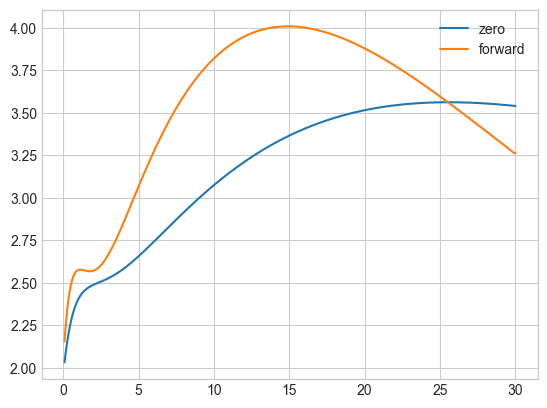

In [10]:
plt.plot(curve["maturity"], curve["zero_rate"], label="zero")
plt.plot(curve["maturity"], curve["forward_rate"]*100, label="forward")
plt.legend()
plt.show()